In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\SUYASH\OneDrive\文档\resources.csv")
df.shape

(783, 27)

In [4]:
resources = pd.read_csv(r"C:\Users\SUYASH\OneDrive\文档\resources_rows.csv")
resources.shape

(816, 37)

In [5]:
interaction = pd.read_csv(r"C:\Users\SUYASH\OneDrive\文档\interactions_ml_rows.csv")
# interaction.info()

In [6]:
df_interaction_train = pd.read_csv(r"C:\Users\SUYASH\OneDrive\文档\interactions_training_view_rows.csv")
# df_interaction_train.info()

In [7]:
resources.head()

,id,title,description,link,category,difficulty,is_free,icon,color,related_skills,...,recommend_percent,total_votes,total_reviews,subdomain,learning_outcomes,quality_score,recommended_stage,skill_node_id,domain,language
0,00790e06-2bff-4a02-9e33-b6335aa25cd9,Figma UI Design Masterclass,Complete Figma course from basics to advanced ...,https://www.udemy.com/course/figma-ui-ux-design/,Design,beginner,False,📚,blue,"[""Figma"",""UI design"",""components"",""auto layout""]",...,NaN,0,0,Design,"[""Complete Figma course from basics to advance...",0,any,dea6d9a1-7aac-4edb-8928-7b6d5f7654f0,Arts & Design,English
1,00bf85fd-ac2d-4018-b875-703aea4e5c03,Tutorials Dojo AWS Practice,Best AWS practice exams,https://tutorialsdojo.com/aws-cheat-sheets/,AWS,intermediate,False,📝,blue,"[""Practice Exams"",""Cheat Sheets""]",...,97.0,84000,0,AWS,[],0,any,01e4ef41-bd1b-472e-adce-3365d3fdc39c,Exam Prep,English
2,00efbf6c-99b5-4927-afae-d04f13c54412,Prometheus Documentation,Monitoring and alerting toolkit,https://prometheus.io/docs/,DevOps,intermediate,True,📊,orange,"[""Prometheus"",""Monitoring"",""Metrics""]",...,94.0,8200,0,DevOps,"[""Monitoring and alerting toolkit""]",0,any,f528dbc9-b8fe-4173-98f4-edeffaae4ea5,Technology,English
3,00fce7cc-b160-46a0-bec1-60b0ccc47634,Data Scientist,Comprehensive data science learning path. From...,https://roadmap.sh/data-science,Data Science,intermediate,True,Database,from-blue-500 to-cyan-500,"[""Python"",""Statistics"",""Machine Learning"",""SQL...",...,NaN,0,0,Data Science,"[""Comprehensive data science learning path."",""...",0,any,9fbd93e1-eb5f-433d-865c-45c37c6a72a3,AI & Data,English
4,0111a193-eac4-4d6c-bebe-684d99e1db67,Supabase Complete Course,Build full-stack apps with Supabase - Postgres...,https://www.udemy.com/course/supabase-course/,Database,intermediate,False,📚,blue,"[""Supabase"",""Postgres"",""Auth"",""Realtime""]",...,NaN,0,0,Database,"[""Build full-stack apps with Supabase - Postgr...",0,any,3ce99da4-7e96-4de4-ac8b-4c4709275123,Technology,English


In [8]:
resources.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    816 non-null    object 
 1   title                 816 non-null    object 
 2   description           816 non-null    object 
 3   link                  816 non-null    object 
 4   category              816 non-null    object 
 5   difficulty            816 non-null    object 
 6   is_free               816 non-null    bool   
 7   icon                  816 non-null    object 
 8   color                 816 non-null    object 
 9   related_skills        816 non-null    object 
 10  relevant_backgrounds  816 non-null    object 
 11  provider              801 non-null    object 
 12  duration              672 non-null    object 
 13  rating                157 non-null    float64
 14  is_featured           816 non-null    bool   
 15  is_active             8

In [9]:
#check for duplicate
resources.duplicated().sum()

np.int64(0)

In [10]:
resources["id"].duplicated().sum()

np.int64(0)

In [11]:
resources["title"].duplicated().sum()

np.int64(33)

In [12]:
missing_percent = (
    resources.isnull()
    .mean()*100
).sort_values(ascending=False)

missing_percent

estimated_time          98.039216
rating                  80.759804
avg_rating              77.573529
recommend_percent       77.573529
weighted_rating         77.573529
duration                17.647059
skill_node_id            7.230392
provider                 1.838235
category                 0.000000
id                       0.000000
link                     0.000000
description              0.000000
title                    0.000000
related_skills           0.000000
is_featured              0.000000
is_active                0.000000
difficulty               0.000000
color                    0.000000
icon                     0.000000
relevant_backgrounds     0.000000
is_free                  0.000000
target_countries         0.000000
section_type             0.000000
resource_type            0.000000
updated_at               0.000000
created_at               0.000000
education_levels         0.000000
total_ratings            0.000000
prerequisites            0.000000
total_votes   

In [13]:
content_df = resources[
    [
        "title",
        "description",
        "domain",
        "subdomain",
        "difficulty",
        "related_skills",
        "learning_outcomes",
        "resource_type"
    ]
].copy()

In [14]:
content_df.head()

,title,description,domain,subdomain,difficulty,related_skills,learning_outcomes,resource_type
0,Figma UI Design Masterclass,Complete Figma course from basics to advanced ...,Arts & Design,Design,beginner,"[""Figma"",""UI design"",""components"",""auto layout""]","[""Complete Figma course from basics to advance...",course
1,Tutorials Dojo AWS Practice,Best AWS practice exams,Exam Prep,AWS,intermediate,"[""Practice Exams"",""Cheat Sheets""]",[],course
2,Prometheus Documentation,Monitoring and alerting toolkit,Technology,DevOps,intermediate,"[""Prometheus"",""Monitoring"",""Metrics""]","[""Monitoring and alerting toolkit""]",website
3,Data Scientist,Comprehensive data science learning path. From...,AI & Data,Data Science,intermediate,"[""Python"",""Statistics"",""Machine Learning"",""SQL...","[""Comprehensive data science learning path."",""...",learning_path
4,Supabase Complete Course,Build full-stack apps with Supabase - Postgres...,Technology,Database,intermediate,"[""Supabase"",""Postgres"",""Auth"",""Realtime""]","[""Build full-stack apps with Supabase - Postgr...",course


In [15]:
content_df[
[
"title",
"related_skills",
"learning_outcomes"
]
].head(5)

,title,related_skills,learning_outcomes
0,Figma UI Design Masterclass,"[""Figma"",""UI design"",""components"",""auto layout""]","[""Complete Figma course from basics to advance..."
1,Tutorials Dojo AWS Practice,"[""Practice Exams"",""Cheat Sheets""]",[]
2,Prometheus Documentation,"[""Prometheus"",""Monitoring"",""Metrics""]","[""Monitoring and alerting toolkit""]"
3,Data Scientist,"[""Python"",""Statistics"",""Machine Learning"",""SQL...","[""Comprehensive data science learning path."",""..."
4,Supabase Complete Course,"[""Supabase"",""Postgres"",""Auth"",""Realtime""]","[""Build full-stack apps with Supabase - Postgr..."


In [16]:
content_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              816 non-null    object
 1   description        816 non-null    object
 2   domain             816 non-null    object
 3   subdomain          816 non-null    object
 4   difficulty         816 non-null    object
 5   related_skills     816 non-null    object
 6   learning_outcomes  816 non-null    object
 7   resource_type      816 non-null    object
dtypes: object(8)
memory usage: 51.1+ KB


In [17]:
text_columns = [
    "title",
    "description",
    "domain",
    "subdomain",
    "difficulty",
    "related_skills",
    "learning_outcomes",
    "resource_type"
]

for col in text_columns:
    content_df[col] = content_df[col].fillna("")

In [18]:
import re

def clean_text(text):

    text = str(text)

    text = text.replace("[", " ")
    text = text.replace("]", " ")

    text = text.replace('"', " ")
    text = text.replace("'", " ")

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [19]:
content_df["related_skills"] = (
    content_df["related_skills"]
    .apply(clean_text)
)

content_df["learning_outcomes"] = (
    content_df["learning_outcomes"]
    .apply(clean_text)
)

In [20]:
content_df[
[
"title",
"related_skills",
"learning_outcomes"
]
].head()

,title,related_skills,learning_outcomes
0,Figma UI Design Masterclass,"Figma , UI design , components , auto layout",Complete Figma course from basics to advanced ...
1,Tutorials Dojo AWS Practice,"Practice Exams , Cheat Sheets",
2,Prometheus Documentation,"Prometheus , Monitoring , Metrics",Monitoring and alerting toolkit
3,Data Scientist,"Python , Statistics , Machine Learning , SQL ,...","Comprehensive data science learning path. , Fr..."
4,Supabase Complete Course,"Supabase , Postgres , Auth , Realtime",Build full-stack apps with Supabase - Postgres...


In [21]:
content_df["combined_text"] = (
    content_df["title"] + " " +
    content_df["description"] + " " +
    content_df["domain"] + " " +
    content_df["subdomain"] + " " +
    content_df["difficulty"] + " " +
    content_df["related_skills"] + " " +
    content_df["learning_outcomes"] + " " +
    content_df["resource_type"]
)

In [22]:
content_df[
[
"title",
"combined_text"
]
].head(3)

,title,combined_text
0,Figma UI Design Masterclass,Figma UI Design Masterclass Complete Figma cou...
1,Tutorials Dojo AWS Practice,Tutorials Dojo AWS Practice Best AWS practice ...
2,Prometheus Documentation,Prometheus Documentation Monitoring and alerti...


In [23]:
content_df["text_length"] = (
    content_df["combined_text"]
    .apply(len)
)

content_df["text_length"].describe()

count    816.000000
mean     242.560049
std       64.902807
min       85.000000
25%      192.000000
50%      259.000000
75%      292.000000
max      425.000000
Name: text_length, dtype: float64

# EDA

In [24]:
resources["domain"].value_counts()

domain
Technology            218
Arts & Design         212
Exam Prep             195
Business & Finance    104
AI & Data              71
General Studies        16
Name: count, dtype: int64

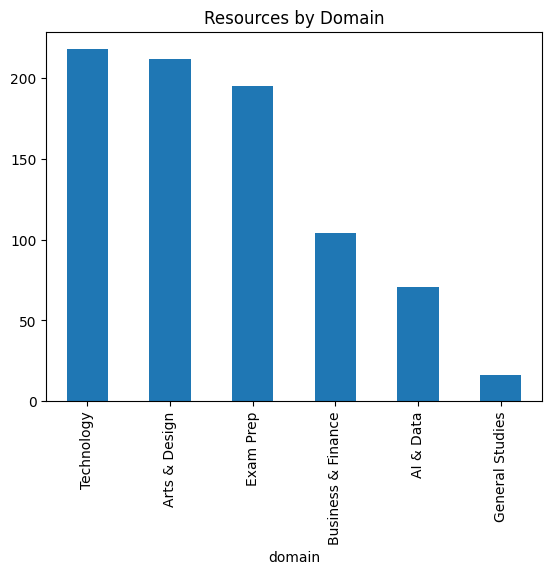

In [25]:
import matplotlib.pyplot as plt

resources["domain"].value_counts().plot(
    kind="bar"
)

plt.title("Resources by Domain")
plt.show()

In [26]:
resources["difficulty"].value_counts()

difficulty
intermediate    418
beginner        297
advanced         98
expert            3
Name: count, dtype: int64

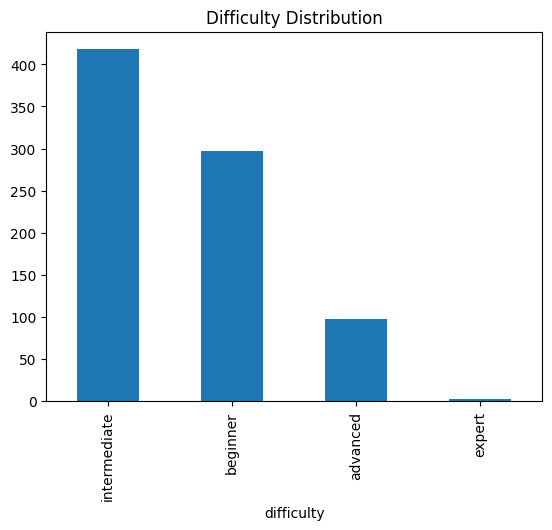

In [27]:
resources["difficulty"].value_counts().plot(
    kind="bar"
)

plt.title("Difficulty Distribution")
plt.show()

In [28]:
resources["resource_type"].value_counts().head(10)

resource_type
course           480
website           85
video             54
blog              40
certification     39
exam_prep         35
book              35
learning_path     26
project            7
degree             6
Name: count, dtype: int64

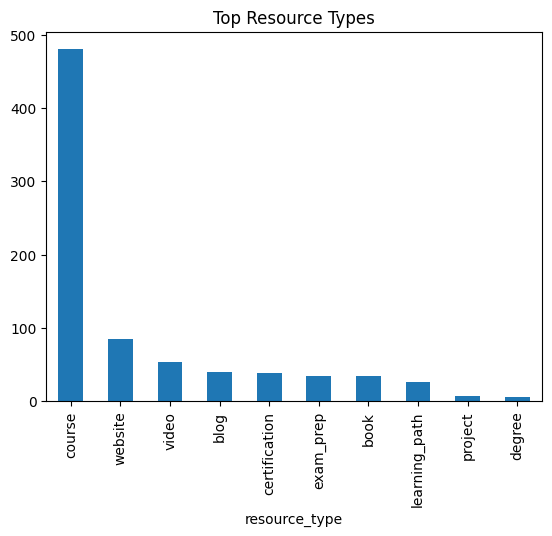

In [29]:
resources["resource_type"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Resource Types")
plt.show()

In [30]:
#check for duplicate
duplicate_titles = (
    resources[
        resources["title"]
        .duplicated(keep=False)
    ]
    .sort_values("title")
)

duplicate_titles[
[
"title",
"domain",
"subdomain"
]
]

,title,domain,subdomain
781,3Blue1Brown Neural Networks,AI & Data,AI/ML
414,3Blue1Brown Neural Networks,AI & Data,Data Science
21,A Cloud Guru,Technology,Cloud Computing
376,A Cloud Guru,Technology,Cloud Computing
351,AWS Solutions Architect Associate,Technology,Cloud Computing
...,...,...,...
513,The Odin Project,Technology,Web Development
397,Towards Data Science,AI & Data,Data Science
473,Towards Data Science,AI & Data,Data Science
537,TryHackMe,Technology,Cybersecurity


# TF-IDF Vectorization (Base Model)

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [33]:
content_df["combined_text"] = (
    content_df["title"] + " " +
    content_df["title"] + " " +
    content_df["title"] + " " +
    
    content_df["domain"] + " " +
    content_df["domain"] + " " +
    
    content_df["subdomain"] + " " +
    content_df["subdomain"] + " " +
    content_df["subdomain"] + " " +
    
    content_df["related_skills"] + " " +
    content_df["related_skills"] + " " +
    
    content_df["learning_outcomes"] + " " +
    
    content_df["description"] + " " +
    
    content_df["difficulty"] + " " +
    content_df["resource_type"]
)

In [34]:
tfidf_matrix = tfidf.fit_transform(
    content_df["combined_text"]
)

In [35]:
print(tfidf_matrix.shape)

(816, 2501)


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

In [37]:
similarity_matrix = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

In [38]:
print(similarity_matrix.shape)

(816, 816)


In [39]:
#Create Index Mapping
indices = pd.Series(
    content_df.index,
    index=content_df["title"]
).drop_duplicates()

In [40]:
#Recommendation Function
def recommend_resources(title, top_n=10):

    if title not in indices:
        return "Resource not found"

    idx = content_df[
        content_df["title"] == title
    ].index[0]

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    resource_indices = [
        i[0]
        for i in similarity_scores
    ]

    result = content_df.iloc[
        resource_indices
    ][
        [
            "title",
            "domain",
            "subdomain",
            "difficulty"
        ]
    ]

    return result

In [41]:
recommend_resources("Data Scientist")
recommend_resources("A Cloud Guru")
recommend_resources("TryHackMe")
recommend_resources("The Odin Project")

,title,domain,subdomain,difficulty
513,The Odin Project,Technology,Web Development,beginner
555,FreeCodeCamp,Technology,Web Development,beginner
226,freeCodeCamp,Technology,Web Development,beginner
137,freeCodeCamp Full Stack,Technology,Web Development,beginner
12,Full-Stack Web Developer,Technology,Web Development,intermediate
260,Full Stack Open,Technology,Web Development,intermediate
774,CSS-Tricks,Technology,Web Development,beginner
174,Traversy Media,Technology,Web Development,beginner
455,Next.js Learn,Technology,Web Development,intermediate
598,React JS Full Course,Technology,Web Development,intermediate


In [42]:
recommend_resources("Data Scientist")

,title,domain,subdomain,difficulty
373,IBM Data Science Professional,AI & Data,Data Science,beginner
397,Towards Data Science,AI & Data,Data Science,intermediate
525,Kaggle Learn,AI & Data,Data Science,beginner
435,Scikit-learn Documentation,AI & Data,Data Science,intermediate
473,Towards Data Science,AI & Data,Data Science,intermediate
668,DataCamp,AI & Data,Data Science,beginner
409,Kaggle,AI & Data,Data Science,intermediate
599,Python Data Science Handbook,AI & Data,Data Science,beginner
125,Coursera Data Science Specialization,AI & Data,Data Science,beginner
540,Hands-On Machine Learning,AI & Data,Data Science,intermediate


In [43]:
recommend_resources("A Cloud Guru")

,title,domain,subdomain,difficulty
376,A Cloud Guru,Technology,Cloud Computing,beginner
627,Cloud Resume Challenge,Technology,Cloud Computing,beginner
202,AWS Cloud Practitioner,Technology,Cloud Computing,beginner
114,Google Cloud Professional,Technology,Cloud Computing,intermediate
688,Microsoft Azure Administrator,Technology,Cloud Computing,intermediate
40,The Cloud Girl YouTube,Technology,Cloud Computing,beginner
793,Microsoft Learn Azure,Technology,Cloud Computing,beginner
90,Cloud Computing Basics - What is Cloud?,Technology,Cloud Computing,beginner
351,AWS Solutions Architect Associate,Technology,Cloud Computing,intermediate
664,AWS Cloud Practitioner Essentials,Technology,Cloud Computing,beginner


In [44]:
recommend_resources("TryHackMe")

,title,domain,subdomain,difficulty
537,TryHackMe,Technology,Cybersecurity,beginner
255,HackTheBox,Technology,Cybersecurity,intermediate
425,Cybrary,Technology,Cybersecurity,beginner
445,The Cyber Mentor,Technology,Cybersecurity,beginner
787,Cybersecurity Analyst,Technology,Cybersecurity,intermediate
516,Hack The Box,Technology,Cybersecurity,intermediate
504,VulnHub,Technology,Cybersecurity,intermediate
493,Offensive Security OSCP,Technology,Cybersecurity,advanced
386,LiveOverflow,Technology,Cybersecurity,intermediate
760,SANS Cyber Aces,Technology,Cybersecurity,beginner


In [45]:
#Converage
all_recommendations = set()

for title in content_df["title"].unique():

    try:
        recs = recommend_resources(
            title,
            top_n=10
        )

        all_recommendations.update(
            recs["title"].tolist()
        )

    except:
        pass

coverage = (
    len(all_recommendations)
    /
    len(content_df)
)

print("Coverage:", coverage)

Coverage: 0.9448529411764706


In [46]:
#Diversity

def diversity_score(title):

    idx = content_df[
        content_df["title"] == title
    ].index[0]

    scores = list(
        enumerate(similarity_matrix[idx])
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )[1:11]

    rec_indices = [
        x[0]
        for x in scores
    ]

    sims = similarity_matrix[
        np.ix_(
            rec_indices,
            rec_indices
        )
    ]

    upper = sims[
        np.triu_indices_from(
            sims,
            k=1
        )
    ]

    return 1 - upper.mean()

In [47]:
diversities = []

for title in content_df["title"].unique():

    try:
        diversities.append(
            diversity_score(title)
        )

    except:
        pass

print(
    "Average Diversity:",
    np.mean(diversities)
)

Average Diversity: 0.67842066328074


| Metric             | Result | Assessment |
| ------------------ | ------ | ---------- |
| Coverage           | 94.49% | Excellent  |
| Diversity          | 0.678  | Very Good  |
| Manual Evaluation  | Good   | Very Good  |
| Domain Matching    | Good   | Very Good  |
| Subdomain Matching | Good   | Very Good  |


In [48]:
df_interaction_train.head()

,user_id,item_id,item_type,total_score,interaction_count
0,34d6e106-073f-4ad2-a27c-b0cf3aaf3a29,3ad8aa79-fb4e-4dec-a621-3791d2506e60,resource,-2.0,1
1,34d6e106-073f-4ad2-a27c-b0cf3aaf3a29,e2964dcc-6570-4ab0-b0d2-03c123722c90,resource,-2.0,1
2,34d6e106-073f-4ad2-a27c-b0cf3aaf3a29,0134d407-9a63-46b4-b563-941c741657dc,resource,1.0,1
3,34d6e106-073f-4ad2-a27c-b0cf3aaf3a29,1ca71b78-462b-41d6-9dfd-6e6f2a540840,resource,3.0,2
4,34d6e106-073f-4ad2-a27c-b0cf3aaf3a29,8790684b-0bba-45d4-8349-783399da5421,resource,-2.0,1


In [49]:
df_interaction_train.columns

Index(['user_id', 'item_id', 'item_type', 'total_score', 'interaction_count'], dtype='object')

In [50]:
print(resources["id"].nunique())
print(df_interaction_train["item_id"].nunique())

816
607


In [51]:
matched_items = df_interaction_train["item_id"].isin(
    resources["id"]
).sum()

print("Matched Items:", matched_items)
print("Total Training Items:", len(df_interaction_train))

Matched Items: 2019
Total Training Items: 2019


In [52]:
#Create resource id mapping
id_to_index = pd.Series(
    content_df.index,
    index=resources["id"]
)

In [53]:
#create reverse mapping
index_to_id = pd.Series(
    resources["id"].values,
    index=content_df.index
)

In [54]:
def recommend_by_id(resource_id, top_n=10):

    idx = id_to_index[resource_id]

    sim_scores = list(
        enumerate(similarity_matrix[idx])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:top_n+1]

    rec_ids = [
        index_to_id[i[0]]
        for i in sim_scores
    ]

    return rec_ids

In [55]:
def precision_at_k(df_interaction_train, k=10):

    precisions = []

    for user in df_interaction_train["user_id"].unique():

        user_items = df_interaction_train[
            df_interaction_train["user_id"] == user
        ]["item_id"].tolist()

        if len(user_items) < 2:
            continue

        hits = 0
        total = 0

        for item in user_items:

            try:

                recs = recommend_by_id(
                    item,
                    top_n=k
                )

                actual_items = set(user_items)

                hit_count = len(
                    set(recs)
                    &
                    actual_items
                )

                hits += hit_count

                total += k

            except:
                pass

        if total > 0:
            precisions.append(
                hits / total
            )

    return np.mean(precisions)

In [56]:
precision_10 = precision_at_k(
    df_interaction_train,
    k=10
)

print(
    "Precision@10:",
    precision_10
)

Precision@10: 0.3184817226069895


# Content-Based Recommender V1 (TF-IDF)

Dataset:
- Resources: 816
- Users: 16
- Interactions: 2019

Features Used:
- Title
- Description
- Domain
- Subdomain
- Difficulty
- Related Skills
- Learning Outcomes
- Resource Type

Model:
- Weighted TF-IDF
- Cosine Similarity

Evaluation:
- Coverage: 94.5%
- Diversity: 0.678
- Precision@10: 0.318

Observations:
- Strong domain matching
- Strong subdomain matching
- Good recommendation quality across AI, Cloud, Web, and Cybersecurity

# Sentence Transformer Recommender

In [57]:
from sentence_transformers import SentenceTransformer

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [58]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4128.76it/s]


In [59]:
content_df["combined_text"]

0      Figma UI Design Masterclass Figma UI Design Ma...
1      Tutorials Dojo AWS Practice Tutorials Dojo AWS...
2      Prometheus Documentation Prometheus Documentat...
3      Data Scientist Data Scientist Data Scientist A...
4      Supabase Complete Course Supabase Complete Cou...
                             ...                        
811    Novel Writing Workshop Novel Writing Workshop ...
812    Stephane Maarek AWS Courses Stephane Maarek AW...
813    Financial Risk Management - GARP Financial Ris...
814    SketchUp for Interior Design SketchUp for Inte...
815    Physics Wallah JEE Complete Course Physics Wal...
Name: combined_text, Length: 816, dtype: object

In [60]:
embeddings = model.encode(
    content_df["combined_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Batches: 100%|██████████| 26/26 [00:06<00:00,  3.83it/s]


In [61]:
print(embeddings.shape)

(816, 384)


In [62]:
from sklearn.metrics.pairwise import cosine_similarity

embedding_similarity = cosine_similarity(
    embeddings,
    embeddings
)

In [63]:
print(embedding_similarity.shape)

(816, 816)


In [64]:
def recommend_embeddings(title, top_n=10):

    idx = content_df[
        content_df["title"] == title
    ].index[0]

    scores = list(
        enumerate(
            embedding_similarity[idx]
        )
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    scores = scores[1:top_n+1]

    indices = [
        i[0]
        for i in scores
    ]

    return content_df.iloc[
        indices
    ][
        [
            "title",
            "domain",
            "subdomain",
            "difficulty"
        ]
    ]

In [65]:
recommend_embeddings("Data Scientist")

recommend_embeddings("A Cloud Guru")

recommend_embeddings("TryHackMe")

recommend_embeddings("The Odin Project")

,title,domain,subdomain,difficulty
513,The Odin Project,Technology,Web Development,beginner
226,freeCodeCamp,Technology,Web Development,beginner
137,freeCodeCamp Full Stack,Technology,Web Development,beginner
555,FreeCodeCamp,Technology,Web Development,beginner
174,Traversy Media,Technology,Web Development,beginner
260,Full Stack Open,Technology,Web Development,intermediate
420,Frontend Masters,Technology,Web Development,intermediate
12,Full-Stack Web Developer,Technology,Web Development,intermediate
257,Svelte & SvelteKit Complete Course,Technology,JavaScript,intermediate
455,Next.js Learn,Technology,Web Development,intermediate


In [66]:
#Evluation
#1) Coverage
def recommend_embeddings(title, top_n=10):

    idx = content_df[
        content_df["title"] == title
    ].index[0]

    scores = list(
        enumerate(
            embedding_similarity[idx]
        )
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    scores = scores[1:top_n+1]

    indices = [
        i[0]
        for i in scores
    ]

    return content_df.iloc[
        indices
    ]

In [67]:
all_recommendations = set()

for title in content_df["title"].unique():

    try:

        recs = recommend_embeddings(
            title,
            top_n=10
        )

        all_recommendations.update(
            recs["title"].tolist()
        )

    except:
        pass

coverage = (
    len(all_recommendations)
    /
    len(content_df)
)

print("Coverage:", coverage)

Coverage: 0.9485294117647058


In [68]:
#Diversity

def diversity_score(title):

    idx = content_df[
        content_df["title"] == title
    ].index[0]

    scores = list(
        enumerate(embedding_similarity[idx])
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )[1:11]

    rec_indices = [
        x[0]
        for x in scores
    ]

    sims = embedding_similarity[
        np.ix_(
            rec_indices,
            rec_indices
        )
    ]

    upper = sims[
        np.triu_indices_from(
            sims,
            k=1
        )
    ]

    return 1 - upper.mean()

In [69]:
diversities = []

for title in content_df["title"].unique():

    try:
        diversities.append(
            diversity_score(title)
        )

    except:
        pass

print(
    "Average Diversity:",
    np.mean(diversities)
)

Average Diversity: 0.4601857


In [70]:
id_to_index = pd.Series(
    content_df.index,
    index=resources["id"]
)

index_to_id = pd.Series(
    resources["id"].values,
    index=content_df.index
)

In [71]:
def recommend_by_id_embeddings(resource_id, top_n=10):

    idx = id_to_index[resource_id]

    sim_scores = list(
        enumerate(
            embedding_similarity[idx]
        )
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:top_n+1]

    rec_ids = [
        index_to_id[i[0]]
        for i in sim_scores
    ]

    return rec_ids

In [72]:
import numpy as np

def precision_at_k_embeddings(df_interaction_train, k=10):

    precisions = []

    for user in df_interaction_train["user_id"].unique():

        user_items = df_interaction_train[
            df_interaction_train["user_id"] == user
        ]["item_id"].tolist()

        if len(user_items) < 2:
            continue

        hits = 0
        total = 0

        for item in user_items:

            try:

                recs = recommend_by_id_embeddings(
                    item,
                    top_n=k
                )

                actual_items = set(user_items)

                hit_count = len(
                    set(recs) & actual_items
                )

                hits += hit_count

                total += k

            except Exception:
                pass

        if total > 0:
            precisions.append(
                hits / total
            )

    return np.mean(precisions)

In [73]:
precision_10_embeddings = precision_at_k_embeddings(
    df_interaction_train,
    k=10
)

print(
    "Embedding Precision@10:",
    precision_10_embeddings
)

Embedding Precision@10: 0.3196654014948962


In [74]:
# #Save TF-IDF Model
# import joblib

# joblib.dump(
#     tfidf,
#     "tfidf_vectorizer.pkl"
# )

In [75]:
# joblib.dump(
#     similarity_matrix,
#     "similarity_matrix.pkl"
# )

In [76]:
# content_df.to_csv(
#     "content_df.csv",
#     index=False
# )

In [77]:
#Printing recommendation for a resource id = 429
recommend_by_id_embeddings(429)

C:\Users\SUYASH\AppData\Local\Temp\ipykernel_21668\2071343221.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  idx = id_to_index[resource_id]


['1f225f9f-ad75-487b-8fda-7af93dfe614b',
 'bcbf8884-a5ff-40b8-87a2-197ec980fc76',
 'a9e360e1-aaad-4ec9-b830-ed7cb3b52d3d',
 '8ca8309c-6e92-4c40-b931-6c1aef528b43',
 '18096374-2a0e-46fb-8a33-c726dd04d7a4',
 'a1eb37f0-e318-43a9-9303-b0df41e01fc0',
 '9fed88ab-07fb-459e-9f8f-ae40370827df',
 'db96c268-3df1-4d0c-9330-fc9994bb2ba6',
 '208e465c-e87d-4e76-a9e8-bf46a5436eb2',
 'fd27798c-5ea0-4e09-b02f-796ed426d1ef']

In [78]:
resources[
    resources["id"].isin([
        '1f225f9f-ad75-487b-8fda-7af93dfe614b',
        'bcbf8884-a5ff-40b8-87a2-197ec980fc76',
        'a9e360e1-aaad-4ec9-b830-ed7cb3b52d3d',
        '8ca8309c-6e92-4c40-b931-6c1aef528b43',
        '18096374-2a0e-46fb-8a33-c726dd04d7a4',
        'a1eb37f0-e318-43a9-9303-b0df41e01fc0',
        '9fed88ab-07fb-459e-9f8f-ae40370827df',
        'db96c268-3df1-4d0c-9330-fc9994bb2ba6',
        '208e465c-e87d-4e76-a9e8-bf46a5436eb2',
        'fd27798c-5ea0-4e09-b02f-796ed426d1ef'
    ])
][[
    "title",
    "domain",
    "resource_type",
    "difficulty"
]]

,title,domain,resource_type,difficulty
80,MIT Introduction to Deep Learning,AI & Data,course,beginner
104,Andrew Ng Machine Learning,AI & Data,course,beginner
109,Deep Learning by Ian Goodfellow - Free Book,AI & Data,blog,intermediate
463,End-to-End ML Project Tutorial,AI & Data,project,advanced
521,Mathematics for Machine Learning (Intro),AI & Data,course,beginner
525,Kaggle Learn,AI & Data,course,beginner
540,Hands-On Machine Learning,AI & Data,book,intermediate
611,Machine Learning Specialization,AI & Data,course,beginner
689,DeepLearning.AI Specialization,AI & Data,course,intermediate
808,Deep Learning Specialization,AI & Data,course,intermediate


In [79]:
resources.loc[429, ["title", "domain", "resource_type"]]

title            Machine Learning by Andrew Ng
domain                               AI & Data
resource_type                           course
Name: 429, dtype: object

### Project Title

**Skill-Metric Content-Based Resource Recommendation System (V1)**

### Objective

Build a personalized resource recommendation system for Skill-Metric that recommends similar learning resources based on resource content and metadata.

---

### Dataset

#### Resources Dataset

```text
Total Resources: 816
Features: 37
```

Important Features Used:

```text
Title
Description
Domain
Subdomain
Difficulty
Related Skills
Learning Outcomes
Resource Type
```

#### Interaction Dataset

```text
Users: 16
Resources with Interactions: 607
Interactions: 2019
```

---

### Data Preprocessing

Completed:

```text
✓ Missing Value Analysis
✓ Duplicate Analysis
✓ Feature Selection
✓ Text Cleaning
✓ Skills Cleaning
✓ Learning Outcomes Cleaning
✓ Combined Text Creation
```

Feature Weighting:

```text
Title × 3
Subdomain × 3
Domain × 2
Related Skills × 2
Learning Outcomes × 1
Description × 1
```

---

### Model Development

#### Model 1 (Selected Model)

```text
Weighted TF-IDF
+
Cosine Similarity
```

Process:

```text
Resource Metadata
↓
TF-IDF Vectorization
↓
Cosine Similarity Matrix
↓
Top-N Resource Recommendations
```

---

#### Model 2 (Experimental)

```text
Sentence Transformers
(all-MiniLM-L6-v2)
+
Cosine Similarity
```

Built and evaluated for comparison.

---

### Evaluation Metrics

#### TF-IDF Model

```text
Coverage      : 94.49%
Diversity     : 0.678
Precision@10  : 0.318
```

#### Embedding Model

```text
Coverage      : 94.85%
Diversity     : 0.460
Precision@10  : 0.320
```

---

### Model Comparison

| Metric       | TF-IDF | Embeddings |
| ------------ | ------ | ---------- |
| Coverage     | 94.49% | 94.85%     |
| Diversity    | 0.678  | 0.460      |
| Precision@10 | 0.318  | 0.320      |

---

### Final Model Selection

**Winner: Weighted TF-IDF**

Reason:

```text
Nearly identical Precision@10
Higher recommendation diversity
Faster training and inference
Lower computational cost
Easier deployment and maintenance
```

---

### Key Findings

```text
1. Resource metadata is highly informative.
2. Weighted TF-IDF performs extremely well on structured educational data.
3. Embeddings provide minimal improvement for the current dataset.
4. Content-based recommendations successfully match domains and subdomains.
5. Current model is suitable as the production baseline for Skill-Metric.
```

---

### Future Roadmap

```text
✓ Content-Based Recommender (Completed)

Next:
1. Generate Synthetic Users
2. Build Collaborative Filtering
3. Build Hybrid Recommender
4. Build Learning Path Recommendation Engine
```

---

### Conclusion

A production-ready content-based recommendation system was successfully developed for Skill-Metric using a Weighted TF-IDF approach. The model achieved **94.49% coverage**, **0.678 diversity**, and **0.318 Precision@10**, demonstrating strong recommendation quality and making it an effective baseline model for future hybrid recommendation systems. 🚀
